In [1]:
!nvidia-smi

Thu Jun 11 15:34:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install -q kagglehub

In [3]:
import kagglehub

path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Dataset path:", path)

Using Colab cache for faster access to the 'asl-alphabet' dataset.
Dataset path: /kaggle/input/asl-alphabet


In [4]:
import os

print(os.listdir(path))

['asl_alphabet_test', 'asl_alphabet_train']


In [5]:
train_path = f"{path}/asl_alphabet_train/asl_alphabet_train"

print(os.listdir(train_path))

['N', 'R', 'space', 'B', 'I', 'del', 'F', 'H', 'E', 'U', 'M', 'X', 'K', 'Q', 'Y', 'S', 'G', 'A', 'O', 'T', 'V', 'Z', 'C', 'P', 'L', 'W', 'D', 'nothing', 'J']


In [ ]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32,
    label_mode="categorical"
)

In [7]:
class_names = train_ds.class_names

print(class_names)
print("Total Classes:", len(class_names))

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Total Classes: 29


Training

In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 87000 files belonging to 29 classes.
Using 69600 files for training.
Found 87000 files belonging to 29 classes.
Using 17400 files for validation.


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [10]:
for images, labels in train_ds.take(1):
    print("Image Batch Shape:", images.shape)
    print("Label Batch Shape:", labels.shape)

Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32, 29)


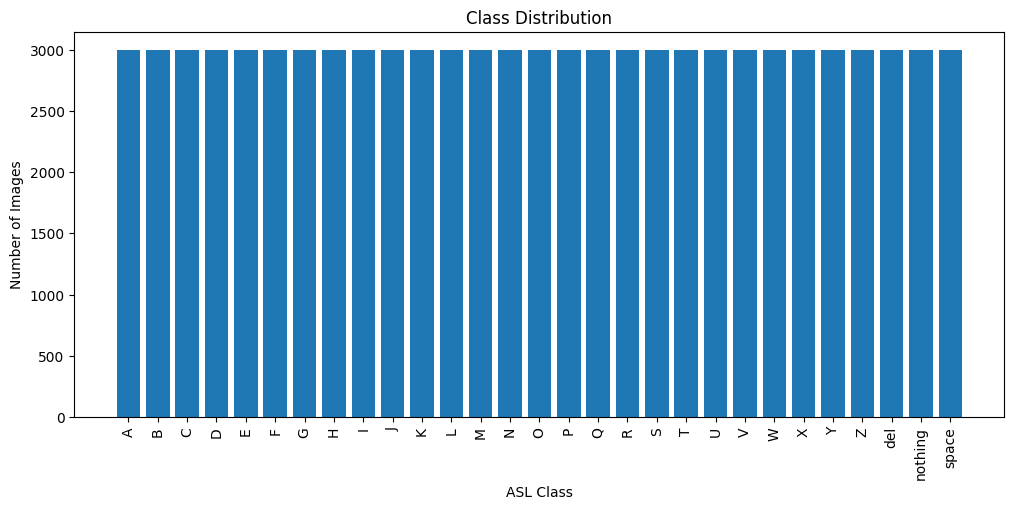

In [11]:
import pandas as pd
import matplotlib.pyplot as plt


class_counts = []

for cls in class_names:
    count = len(os.listdir(os.path.join(train_path, cls)))
    class_counts.append(count)

df = pd.DataFrame({
    "Class": class_names,
    "Count": class_counts
})

plt.figure(figsize=(12,5))
plt.bar(df["Class"], df["Count"])
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("ASL Class")
plt.ylabel("Number of Images")
plt.show()

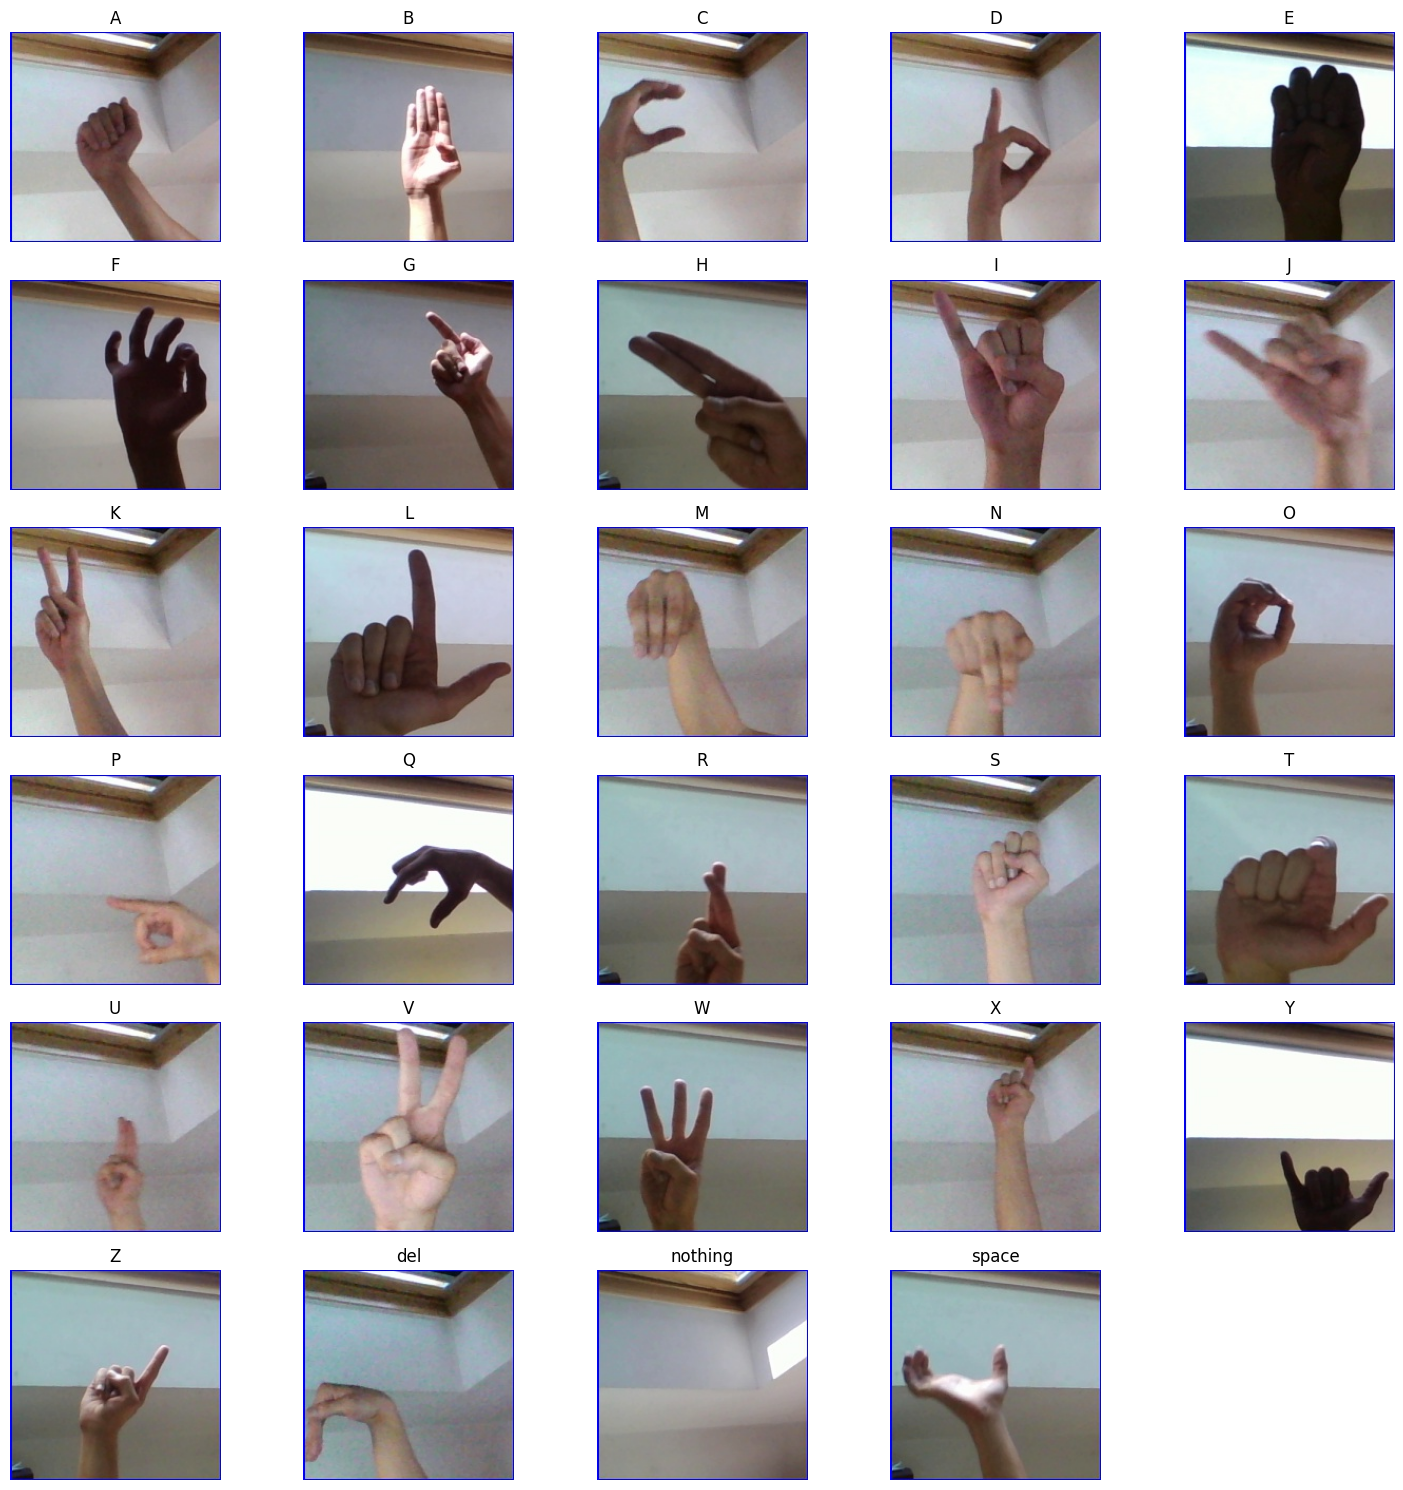

In [12]:

from PIL import Image

plt.figure(figsize=(15,15))

for i, cls in enumerate(class_names):
    folder = os.path.join(train_path, cls)

    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)

    img = Image.open(img_path)

    plt.subplot(6, 5, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

Build CNN

In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(224,224,3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(29, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,252,125 (84.89 MB)

 Trainable params: 22,252,125 (84.89 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 312s 139ms/step - accuracy: 0.6224 - loss: 1.1973 - val_accuracy: 0.9517 - val_loss: 0.1852
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 139s 64ms/step - accuracy: 0.8901 - loss: 0.3133 - val_accuracy: 0.9784 - val_loss: 0.0697
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 139s 63ms/step - accuracy: 0.9353 - loss: 0.1872 - val_accuracy: 0.9917 - val_loss: 0.0314
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 136s 63ms/step - accuracy: 0.9521 - loss: 0.1409 - val_accuracy: 0.9924 - val_loss: 0.0255
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 136s 63ms/step - accuracy: 0.9625 - loss: 0.1072 - val_accuracy: 0.9921 - val_loss: 0.0246
Epoch 6/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 136s 62ms/step - accuracy: 0.9690 - loss: 0.0906 - val_accuracy: 0.9955 - val_loss: 0.0130
Epoch 7/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 136s 62ms/step - accuracy: 0.9757 - loss: 0.0760 - val_accuracy: 0.9966 - val_loss: 0.0095
Epoch 8/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 135s 62ms/step - accuracy:

In [66]:
from google.colab import files

uploaded = files.upload()

Saving test.jpg to test (3).jpg


In [67]:
filename = list(uploaded.keys())[0]
print(filename)

test (3).jpg


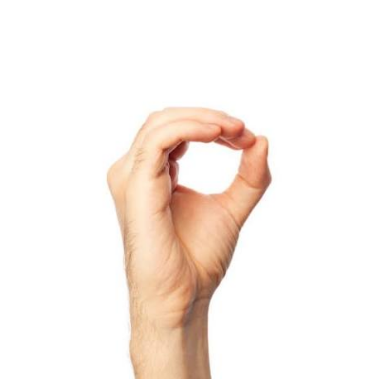

In [68]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np


img = load_img(filename, target_size=(224, 224))
img_array = img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
from PIL import Image

img = Image.open("test (3).jpg")

plt.imshow(img)
plt.axis("off")
plt.show()

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Prediction:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediction: O
Confidence: 100.00%


In [72]:
from google.colab import files

uploaded = files.upload()

Saving test2.jpg to test2 (2).jpg


In [73]:
filename = list(uploaded.keys())[0]
print(filename)

test2 (2).jpg


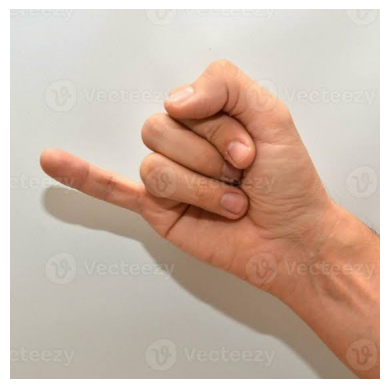

In [76]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np


img = load_img(filename, target_size=(224, 224))
img_array = img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
from PIL import Image

img = Image.open("test2 (2).jpg")

plt.imshow(img)
plt.axis("off")
plt.show()

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Prediction:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Prediction: J
Confidence: 100.00%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Prediction: S
Confidence: 9.408603
